Initialize the SBI task


In [1]:
!pip install git+"https://github.com/nidropakshin2/Sequential-FMPE.git#egg=sfmpe&subdirectory=code"
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126

  Cloning https://github.com/nidropakshin2/Sequential-FMPE.git to /tmp/pip-install-m1edwy_o/sfmpe_05e52641a63a49499987dea62d2a2349
  Running command git clone --filter=blob:none --quiet https://github.com/nidropakshin2/Sequential-FMPE.git /tmp/pip-install-m1edwy_o/sfmpe_05e52641a63a49499987dea62d2a2349
  Resolved https://github.com/nidropakshin2/Sequential-FMPE.git to commit 8ad59d2243a12f1c2019726ed762b7806e10ece2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for sfmpe: filename=sfmpe-0.1.0-py3-none-any.whl size=37931 sha256=69da37b56bf1f4100a87255de92492987eb18fa6b19d2b18d9ae9f2afac01db3
  Stored in directory: /tmp/pip-ephem-wheel-cache-wra8cvf8/wheels/c3/bf/ce/2cc28442a8cc903c0b14c96e16a1d61339868937fd26cbddc9
Successfully built sfmpe
Looking in indexes: https://download.pytorch.org/whl/cu126


In [2]:
config = {
    "prior":
        {
        "gamma_range": [0.05, 0.5],
        "beta_range": [0.5, 5.0],
        },
    "simulator":
        {
        "S": [1500, 2000], # int, tuple, number of Susceptible individuals or bounds for following uniform distribution
        "I": [150, 200], # int, tuple, number of Infectious individuals or bounds for following uniform distribution
        "R": [0, 50], # int, tuple, number of Recovered individuals or bounds for following uniform distribution
        "T": [100, 120],  # int, tuple, simulation duration in days or bounds for following uniform distribution
        },
    "summary": 
        {
        "type": "handmade",
        "input_dim": 3,
        "hidden_dim": 32,
        "num_layers": 2,
        "output_dim": 5,
        "dropout": 0.1,
        },
    "logger":
        {
        "name": "SIR",
        "level": "DEBUG",
        "log_file_path": "logs/sir.log",
        }
}
import os

if not os.path.exists("./logs"):
    os.mkdir("./logs")
if not os.path.exists("./models"):
    os.mkdir("./models")

2026-09-15 17:29:38,866 - SIR - INFO - Starting SIR task
2026-09-15 17:29:42,305 - SIR - INFO - Initialized flow model
2026-09-15 17:29:44,951 - SIR - INFO - Initialized flow matching estimator
2026-09-15 17:29:46,344 - SIR - INFO - Starting SFMPE for theta tensor([[1.2621, 0.4558]], device='cuda:0')
2026-09-15 17:29:46,345 - SIR - INFO - RoundManager initialized with device: cuda
2026-09-15 17:29:46,346 - SIR - INFO - Task: SIRTask
2026-09-15 17:29:46,346 - SIR - INFO - Estimator: FlowMatchingEstimator
2026-09-15 17:29:46,347 - SIR - INFO - Starting sequential training with 3 rounds
2026-09-15 17:29:46,348 - SIR - INFO - Simulations per round: 10000
2026-09-15 17:29:46,349 - SIR - INFO - Training kwargs: {'path': './models/SIR_2026-09-15_17_29_46.pth.tar.gz', 'epochs': 1000, 'show_every': 100, 'device': 'cuda', 'batch_size': 1000, 'shuffle': True, 'num_workers': 0}
2026-09-15 17:29:46,349 - SIR - INFO - --- Round 0/3 ---
2026-09-15 17:29:46,350 - SIR - INFO - Starting round 0 with 100

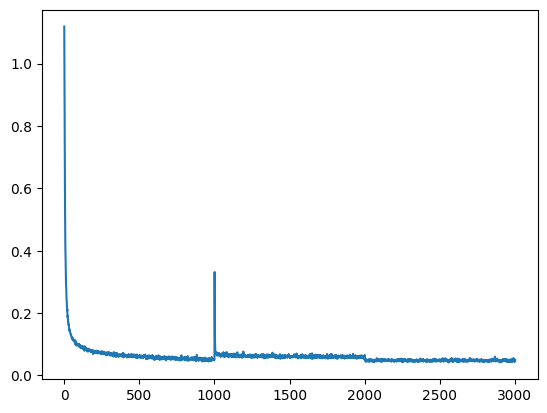

In [3]:
import yaml
import torch
import time
import matplotlib.pyplot as plt

from sfmpe.tasks.SIR import SIRTask


# config_path = './configs/sir_config.yaml'
# with open(config_path) as f:
#     config = yaml.safe_load(f)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
task = SIRTask(config, device)
task.summary.to(device)
logger = task.logger
logger.info("Starting SIR task")

from sfmpe.inference.fm_estimator import FlowMatchingEstimator
from sfmpe.flow.flow_model import FlowModel
from sfmpe.flow.velocity import SimpleVelocityField
from sfmpe.flow.path import AffinePath
from sfmpe.core.distributions import Uniform, Normal


init_dist = Normal(dim=task.theta_dim)
velocity_model = SimpleVelocityField(task.theta_dim, task.data_dim, num_layers=5)
path = AffinePath()
flow_model = FlowModel(velocity_model, init_dist, path)
logger.info("Initialized flow model")

optimizer = torch.optim.Adam([
                        # {"params": task.summary.parameters(), "lr":1e-4},
                        {"params": flow_model.parameters(), "lr":1e-4}
                        ])
loss_fn = torch.nn.MSELoss()

def preprocessor(theta, x):
    s = task.simulate(theta).to(device)
    x = task.summarize(s).to(device)
    return theta, x

flow_model.to(device)
fm_estimator = FlowMatchingEstimator(flow_model, optimizer, loss_fn)#, dataset_prepocessor=preprocessor)
logger.info("Initialized flow matching estimator")

from sfmpe.inference.sequential.round_manager import RoundManager
from sfmpe.inference.sequential.proposal import Proposal, ProposalParams

# theta_0, x_0 = task.simulate_dataset((3,))
# theta_0 = torch.tensor([[1.3, 0.3]]).to(device)
# theta_0 = torch.tensor([[0.025, 0.05],
#                            [0.25, 0.5],
#                            [2.5, 0.5],
#                            [1.25, 0.5],
#                            [0.25, 0.05],
#                            [0.125, 0.05],
#                            [0.125, 0.25],
#                            [1.25, 0.25],
#                            [0.625, 0.25]
#                            ]) 

theta_0 = torch.tensor([[1.2621, 0.4558]]).to(device) 
x_0 = task.summarize(task.simulate(theta_0))
# theta_0, x_0 = theta_0.expand(5, -1), x_0.expand(5, -1)
task.logger.info(f"Starting SFMPE for theta {theta_0}")

params = ProposalParams()
params.task = task
params.method = "Truncated"
params.theta_0 = theta_0
params.x_0 = x_0
params.method_params = {'scale': 0.8, 'quantile': 0.1}


datetime = time.strftime("%Y-%m-%d_%H_%M_%S")
path = f"./models/SIR_{datetime}.pth.tar.gz"

num_rounds = 3
sims_per_round = 10000
sims_per_sample = 1
epochs = 1000
show_every = epochs // 10 

train = True

manager = RoundManager(task, fm_estimator, params, device=device)

if train:
   manager.run_sequential(num_rounds=num_rounds,
                        sims_per_round=sims_per_round,
                        sims_per_sample=sims_per_sample,
                        path=path, epochs=epochs, 
                        show_every=show_every,
                        clean_sampling=True, device=device,
                        batch_size=1000, shuffle=True, num_workers=0)
   loss = manager.losses
   _, ax = plt.subplots()
   ax.plot(loss)
else:
   manager.load_model("./models/SIR_2026-09-15_16_35_02.pth.tar.gz")

In [4]:
# from sbi.inference import SMCABC

# smc = SMCABC(simulator=lambda theta: task.summary(task.simulator.simulate(theta)),
#              prior=task.prior)
# output = smc(x_0, 
#     num_particles=1000,
#     num_initial_pop=5000,
#     num_simulations=5000,
#     epsilon_decay=0.1)
# plt.scatter(torch.log(output[:, 0]), torch.log(output[:, 1]), s=1)
# plt.scatter(torch.log(theta_0[:, 0]), torch.log(theta_0[:, 1]))

In [5]:
# x = task.sample_prior((10000,))

# # a = torch.tensor([0.1, 1.3, 2.4])
# # b = torch.tensor([0.05, 0.3, 0.5])

# # theta_grid = torch.cartesian_prod(a, b)

# theta_grid = torch.tensor([[0.025, 0.05],
#                            [0.25, 0.5],
#                            [2.5, 0.5],
#                            [1.25, 0.5],
#                            [0.25, 0.05],
#                            [0.125, 0.05],
#                            [0.125, 0.25],
#                            [1.25, 0.25],
#                            [0.625, 0.25]
#                            ]) 
# theta_grid = 0.8 * (theta_grid - torch.tensor([0.625, 0.25])) + torch.tensor([0.625, 0.25])
# plt.scatter(x[:, 0], x[:, 1], s=1)
# plt.scatter(theta_grid[:, 0], theta_grid[:, 1], s=10)

2026-09-15 17:39:58,577 - SIR - DEBUG - old x_0: tensor([[ 0.8054, -0.8784, -1.1137, -1.2956,  1.1309]], device='cuda:0'),
new x_0: tensor([[ 0.8383, -0.8932, -1.1168, -1.3138,  1.1508]], device='cuda:0')
2026-09-15 17:39:58,578 - SIR - INFO - Building posterior...


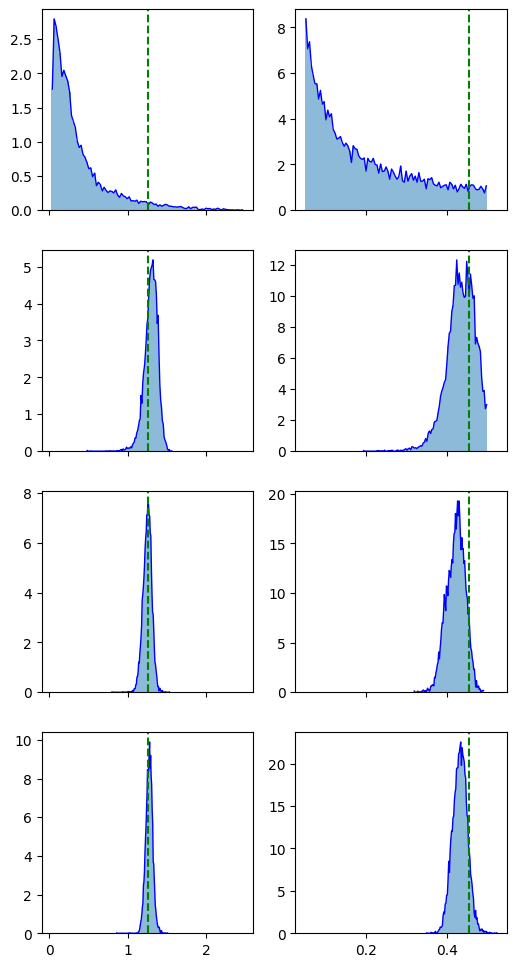

In [6]:
from sfmpe.utils.plotting import dist_plot

sim_store = manager.store
posterior = manager.build_posterior()

dist_plot(
                sim_store.theta[0].detach().cpu(), 
                sim_store.theta[1].detach().cpu(),
                sim_store.theta[2].detach().cpu(),  
                posterior.sample((10000,)).detach().cpu(),
                # manager.clean_sample((1000, )),
                true_param=theta_0.detach().cpu())

tensor([[1.2621, 0.4558]], device='cuda:0') tensor([[1.2749, 0.4327]]) tensor([[0.0461, 0.0188]])


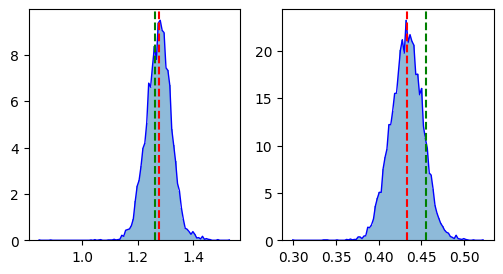

In [7]:
K = 0
pred = posterior.sample((10000,)).detach().cpu()
print(theta_0, pred.mean(dim=0), pred.std(dim=0))

def dist_plot2(*dists, true_param=None, pred_param=None):
    # assert len(dist1.shape) == len(dist2.shape) and dist1.shape[-1] == dist2.shape[-1]
    theta_dim = dists[0].shape[-1]
    K = dists[0].shape[-2]
    num_bins  = [int(dists[i].shape[0] ** 0.5) for i in range(len(dists))]
    
    _, ax = plt.subplots(len(dists), theta_dim, sharex='col', figsize=(3*theta_dim, 3*len(dists)))
    if len(dists) == 1:
        ax = [ax]
    for j in range(theta_dim):
        for thetas, i in zip(dists, range(len(dists))):
            for k in range(K):
                counts, bins, patches = ax[i][j].hist(thetas[:, k, j], bins=num_bins[i], alpha=0.5, density=True)

                bin_centers = (bins[:-1] + bins[1:]) / 2

                ax[i][j].plot(bin_centers, counts, 'b-', linewidth=1)

                if true_param is not None:
                    ax[i][j].axvline(x=true_param[k, j], linestyle='--', color='green')
                
                if pred_param is not None:
                    ax[i][j].axvline(x=pred_param[k, j], linestyle='--', color='red')

dist_plot2(pred[:, K, :].unsqueeze(1).detach().cpu(), true_param=theta_0[K].unsqueeze(0).detach().cpu(), pred_param=pred.mean(dim=0)[K].unsqueeze(0))

In [8]:
# import corner

# for i in range(theta_pred.shape[1]):
#     samples = theta_pred[:, i, :].numpy()
#     fig = corner.corner(samples, bins=40, levels=[0.5], labels=['beta', 'gamma'],
#                         plot_datapoints=False, plot_contours=True, smooth=1)

In [9]:
# def sbc(manager):
#     thetas_prior = manager.task.prior.sample((1000,))
#     num_samples = 1000
#     samples = manager.proposal.sample((num_samples, 1000,))
#     print(samples.shape, thetas_prior[:, None, None, :].shape)
#     ranks = (samples < thetas_prior[:, None, None, :]).sum(dim=-1)
#     print(ranks.shape)
#     return ranks


# ranks = sbc(manager)
# _, ax = plt.subplots(1, 2, figsize=(8, 2.5))
# ax[0].hist(ranks[:, 0].cpu(), bins=20, color="#8000ff")
# ax[1].hist(ranks[:, 1].cpu(), bins=20, color="orange")
